In [2]:

import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
import csv
import re

rho_ratio = '1'
v = '01'
Ux=0.01

folder_path = os.path.join("../data_for_plots",
                           "moving_vs_resting_bubble",
                           "line_data_rho%s_v%s_circular_Ux%s" % (rho_ratio, v, re.sub('[.]', '', str(Ux))[:]))
print(folder_path)

frame_n = 999  # last time-frame

frame_cm_resting = pd.read_csv(os.path.join(folder_path, "cm_resting.%d.csv" % frame_n), delimiter="\t")
frame_mrt_resting = pd.read_csv(os.path.join(folder_path, "mrt_resting.%d.csv" % frame_n), delimiter="\t")
frame_cm_moving = pd.read_csv(os.path.join(folder_path, "cm_moving.%d.csv" % frame_n), delimiter="\t")
frame_mrt_moving = pd.read_csv(os.path.join(folder_path, "mrt_moving.%d.csv" % frame_n), delimiter="\t")
    
u_cm = np.sqrt(frame_cm_resting['U:0']*frame_cm_resting['U:0']+frame_cm_resting['U:1']*frame_cm_resting['U:1'])
u_mrt = np.sqrt(frame_mrt_resting['U:0']*frame_mrt_resting['U:0']+frame_mrt_resting['U:1']*frame_mrt_resting['U:1'])


../data_for_plots/moving_vs_resting_bubble/line_data_rho1_v01_circular_Ux001


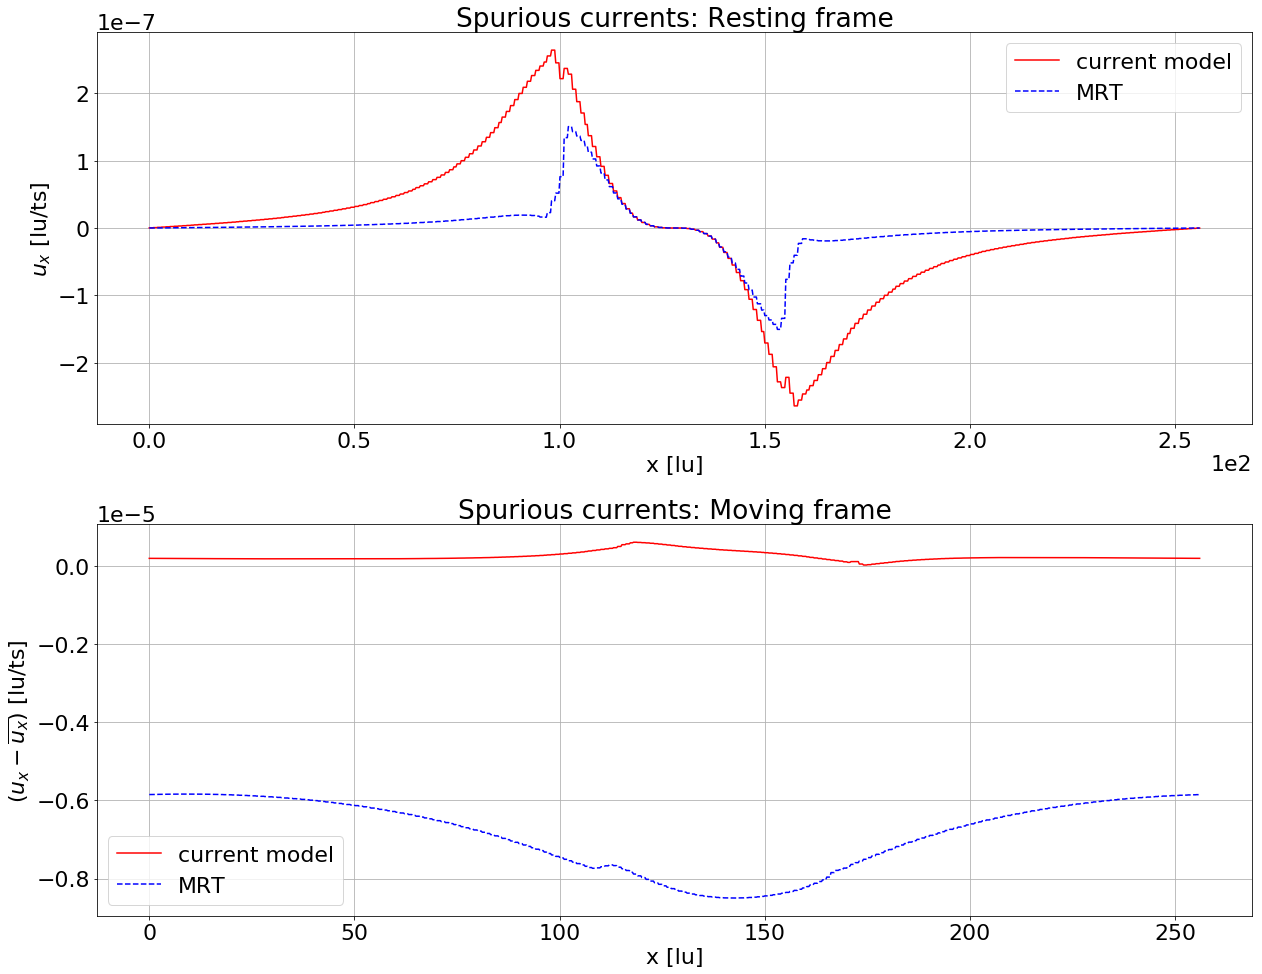

In [3]:

# make plot
plt.figure(1)
plt.figure(figsize=(18, 14))
plt.rcParams.update({'font.size': 22})

# frame_n = 1
# plt.plot(frames_cm_moving[frame_n]['arc_length'], frames_cm_moving[frame_n]['PhaseField'], color="green", marker="", linestyle="-.",  label='cm_test')
# plt.plot(frames_mrt_moving[frame_n]['arc_length'], frames_mrt_moving[frame_n]['PhaseField'], color="red", marker="", linestyle="-", label='mrt_test')

plt.subplot(211)
plt.title('Spurious currents: Resting frame')


plt.plot(frame_cm_resting['arc_length'], frame_cm_resting['U:0'], color="red", marker="", linestyle="-", label='current model')
plt.plot(frame_mrt_resting['arc_length'], frame_mrt_resting['U:0'], color="blue", marker="", linestyle="--", label='MRT')

axes = plt.gca()
# axes.set_xlim([xmin,xmax])
# axes.set_ylim([-3E-7, 3E-7])
plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
plt.xlabel(r'x [lu]')
plt.ylabel(r'$u_{x}$ [lu/ts]')
plt.grid(True)
plt.legend()

plt.subplot(212)
plt.title(r'Spurious currents: Moving frame')
plt.plot(frame_cm_moving['arc_length'], frame_cm_moving['U:0']-Ux, color="red", marker="", linestyle="-", label='current model')
plt.plot(frame_mrt_moving['arc_length'], frame_mrt_moving['U:0']-Ux, color="blue", marker="", linestyle="--", label='MRT')

# plt.plot(line_size, theoretical, color="black", marker="x", linestyle="", label='theoretical')
axes = plt.gca()
# axes.set_xlim([xmin,xmax])
# axes.set_ylim([-5E-7, 5E-7])
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
plt.xlabel(r'x [lu]')
plt.ylabel(r'$(u_{x} - \overline{u_x})$ [lu/ts]')
plt.grid(True)
plt.legend()

fig = plt.gcf()  # get current figure
plt.tight_layout()
fig.savefig('spurious_currents_cm_vs_MRT_rho%s_v%s_Ux%s.png' % (rho_ratio, v, str(Ux)))
plt.show()
